In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from datasets import load_dataset
from torch.utils.data import DataLoader, TensorDataset
from collections import Counter

In [14]:
tmdb = load_dataset('imdb')
train_data = tmdb['train']
test_data = tmdb['test']

In [15]:
vocab_size = 5000
max_length = 200
embedding_dim = 64

In [16]:
count = Counter()
for text in train_data:
    count.update(text['text'].lower().split())

In [17]:
vocab = {}
for idx, (word, _) in enumerate(count.most_common(vocab_size - 2)):
    vocab[word] = idx + 2

In [18]:
vocab['<PAD>'] = 0
vocab['<UNK>'] = 1

In [19]:
def encode_text(text):
    words = text.lower().split()
    encoded = []
    for word in words:
        encoded.append(vocab.get(word, 1))
    if len(encoded) < max_length:
        encoded += [0] * (max_length - len(encoded))
    else:
        encoded = encoded[:max_length]
    return encoded


In [26]:
X_train = torch.tensor([encode_text(text) for text in train_data['text']], dtype=torch.long)
y_train = torch.tensor([sample for sample in train_data['label']], dtype=torch.float32)
X_test = torch.tensor([encode_text(text) for text in test_data['text']], dtype=torch.long)
y_test = torch.tensor([sample for sample in test_data['label']], dtype=torch.float32)

In [27]:
train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=64, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test, y_test), batch_size=64)

In [28]:
class SentimentModel(nn.Module):
    def __init__(self):
        super(SentimentModel, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.fc = nn.Sequential(
            nn.Linear(embedding_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            # nn.Sigmoid()
        )

    def forward(self, x):
        x = self.embedding(x)
        x = x.mean(dim=1)
        x = self.fc(x)
        return x.squeeze(1)


In [29]:
model = SentimentModel()
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
epochs = 10
batch_size = 64

In [30]:
for epoch in range(epochs):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f'Epoch {epoch + 1}/{epochs}, Loss: {total_loss / (len(X_train) / batch_size):.4f}')
model.eval()
    

Epoch 1/10, Loss: 0.6123
Epoch 2/10, Loss: 0.4237
Epoch 3/10, Loss: 0.3589
Epoch 4/10, Loss: 0.3222
Epoch 5/10, Loss: 0.2990
Epoch 6/10, Loss: 0.2794
Epoch 7/10, Loss: 0.2664
Epoch 8/10, Loss: 0.2579
Epoch 9/10, Loss: 0.2475
Epoch 10/10, Loss: 0.2396


SentimentModel(
  (embedding): Embedding(5000, 64)
  (fc): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=1, bias=True)
  )
)

In [31]:
correct = 0
total = 0
with torch.no_grad():
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        predictions = torch.sigmoid(outputs)
        predicted = (
            predictions >= 0.5
        ).float()
        correct += (
            predicted == y_batch
        ).sum().item()
        total += y_batch.size(0)
accuracy = correct / total

print("\nTest Accuracy:", accuracy)


Test Accuracy: 0.83272


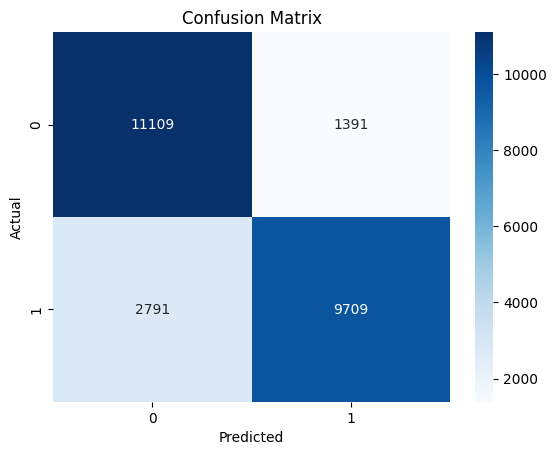

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns
predictions = (torch.sigmoid(model(X_test)) >= 0.5).float()
cm = confusion_matrix(y_test, predictions)
plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()